# Project 1 — Celebrity Detection
## Milestone 2: Synthetic Multi-Face Dataset Construction

**IE 7615** — Project 1, Milestone 2

**David Fung**

Milestone 2 is the second graded checkpoint for Project 1: a discriminative computer-vision pipeline for celebrity identification and detection. At this checkpoint, your team pivots from single-face classification (Milestone 1) to the detection half of the system. You will construct a synthetic multi-celebrity image dataset, annotate each image with YOLO-format bounding boxes, apply a documented augmentation strategy, and produce a clean train/validation/test split that Milestone 3 will consume directly.

This milestone runs in parallel with Module 4's RNN content. There is no RNN component in Project 1 itself; the team work here is the bridge that prepares your dataset for YOLOv8 fine-tuning in Module 5. Strong dataset construction at this checkpoint pays dividends in every downstream metric (mAP, IoU, precision, recall) you will report in Milestone 3.

This milestone constructs a synthetic multi-face detection dataset for YOLOv8 training. Composite images are generated by pasting 2–5 celebrity faces (from the 5 identities in Milestone 1) onto random solid-color backgrounds at 640×640. Each image is paired with a YOLO-format label file. The dataset is split into train (70%), validation (15%), and test (15%).

In [1]:
import os
import random
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.13.1


In [2]:
# PROJECT CONSTANTS
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
tf.keras.utils.set_random_seed(GLOBAL_SEED)

def set_all_seeds():
    np.random.seed(GLOBAL_SEED)
    random.seed(GLOBAL_SEED)
    tf.random.set_seed(GLOBAL_SEED)

# Dataset parameters
SYNTH_IMG_SIZE = 640
SYNTH_MIN_FACES = 2
SYNTH_MAX_FACES = 5
SYNTH_NUM_IMAGES = 200

# Paths
FACE_POOL_DIR = "data/selected_images"
OUTPUT_DIR = "data/synthetic_multi_face"

# Classes (same as Milestone 1)
CLASS_NAMES = ['7', '797', '2619', '4428', '7007']
NUM_CLASSES = 5

## Task 1 — Load Face Pool

Load all face images from the 5 selected identity directories. Each face is stored with its path and class ID for later compositing.

In [3]:
face_pool = []
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(FACE_POOL_DIR, class_name)
    for fname in sorted(os.listdir(class_dir)):
        if fname.endswith(('.jpg', '.png')):
            face_pool.append({
                'path': os.path.join(class_dir, fname),
                'class_id': class_idx,
                'class_name': class_name
            })

print(f"Loaded {len(face_pool)} faces from {NUM_CLASSES} identities")
for i, name in enumerate(CLASS_NAMES):
    count = sum(1 for f in face_pool if f['class_id'] == i)
    print(f"  Class {name}: {count} faces")

Loaded 121 faces from 5 identities
  Class 7: 24 faces
  Class 797: 25 faces
  Class 2619: 25 faces
  Class 4428: 23 faces
  Class 7007: 24 faces


## Task 2 — Generate Synthetic Images

For each synthetic image: create a solid-color background, paste a random number of faces (2–5) at random positions and scales, and record the bounding boxes in YOLO format.

In [4]:
def generate_one_sample():
    """Generate one synthetic image with 2-5 random faces."""
    # Random solid-color background
    color = (random.randint(50, 255), random.randint(50, 255), random.randint(50, 255))
    img = Image.new('RGB', (SYNTH_IMG_SIZE, SYNTH_IMG_SIZE), color)
    
    # Random number of faces
    num_faces = random.randint(SYNTH_MIN_FACES, SYNTH_MAX_FACES)
    
    labels = []
    for _ in range(num_faces):
        # Randomly select a face from the pool
        face_info = random.choice(face_pool)
        face_img = Image.open(face_info['path']).convert('RGB')
        
        # Random scale (15% to 50% of image size)
        scale = random.uniform(0.15, 0.50)
        face_w = int(SYNTH_IMG_SIZE * scale)
        face_h = int(face_w * face_img.height / face_img.width)
        
        # Clamp to minimum size
        min_size = int(SYNTH_IMG_SIZE * 0.12)
        face_w = max(face_w, min_size)
        face_h = max(face_h, min_size)
        
        # Random position (face must fit entirely within the image)
        x = random.randint(0, SYNTH_IMG_SIZE - face_w)
        y = random.randint(0, SYNTH_IMG_SIZE - face_h)
        
        # Resize and paste
        face_resized = face_img.resize((face_w, face_h), Image.LANCZOS)
        img.paste(face_resized, (x, y))
        
        # YOLO label: class_id, x_center, y_center, width, height (all normalized)
        labels.append((
            face_info['class_id'],
            (x + face_w / 2) / SYNTH_IMG_SIZE,
            (y + face_h / 2) / SYNTH_IMG_SIZE,
            face_w / SYNTH_IMG_SIZE,
            face_h / SYNTH_IMG_SIZE
        ))
    
    return img, labels


def save_sample(image, labels, save_dir, name):
    """Save one image + label file to the output directory."""
    img_path = os.path.join(save_dir, 'images', f'{name}.jpg')
    lbl_path = os.path.join(save_dir, 'labels', f'{name}.txt')
    os.makedirs(os.path.dirname(img_path), exist_ok=True)
    os.makedirs(os.path.dirname(lbl_path), exist_ok=True)
    
    image.save(img_path, quality=95)
    
    with open(lbl_path, 'w') as f:
        for cls, cx, cy, w, h in labels:
            f.write(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

In [5]:
set_all_seeds()

temp_dir = os.path.join(OUTPUT_DIR, "temp")
os.makedirs(temp_dir, exist_ok=True)

print(f"Generating {SYNTH_NUM_IMAGES} synthetic images...")
all_samples = []
for i in range(SYNTH_NUM_IMAGES):
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{SYNTH_NUM_IMAGES}")
    img, labels = generate_one_sample()
    name = f"synthetic_{i:04d}"
    save_sample(img, labels, temp_dir, name)
    all_samples.append({
        'name': name,
        'num_faces': len(labels),
        'classes': [l[0] for l in labels]
    })

print(f"\nGenerated {SYNTH_NUM_IMAGES} synthetic images")
df_samples = pd.DataFrame(all_samples)
print(f"Average faces per image: {df_samples['num_faces'].mean():.2f}")

Generating 200 synthetic images...
  50/200
  100/200
  150/200
  200/200

Generated 200 synthetic images
Average faces per image: 3.46


## Task 3 — Split Dataset

Split the generated samples into train (70%), validation (15%), and test (15%) directories, moving both images and label files.

In [6]:
# Collect all sample names
sample_names = [os.path.splitext(os.path.basename(p))[0]
                for p in glob.glob(os.path.join(temp_dir, 'images', '*.jpg'))]

# Stratified split
train_names, temp_names = train_test_split(sample_names, test_size=0.30, random_state=GLOBAL_SEED)
val_names, test_names = train_test_split(temp_names, test_size=0.5, random_state=GLOBAL_SEED)

print(f"Train: {len(train_names)}, Val: {len(val_names)}, Test: {len(test_names)}")

# Move files into split directories
for split_name, names in [('train', train_names), ('val', val_names), ('test', test_names)]:
    img_dir = os.path.join(OUTPUT_DIR, 'images', split_name)
    lbl_dir = os.path.join(OUTPUT_DIR, 'labels', split_name)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)
    
    for name in names:
        shutil.move(os.path.join(temp_dir, 'images', f'{name}.jpg'), img_dir)
        shutil.move(os.path.join(temp_dir, 'labels', f'{name}.txt'), lbl_dir)

# Remove temp directory
shutil.rmtree(temp_dir)
print("Split complete.")

Train: 140, Val: 30, Test: 30
Split complete.


## Task 4 — Create data.yaml

Write the YOLOv8 dataset configuration file pointing to the generated splits and listing class names.

In [7]:
yaml_lines = [
    f"path: {OUTPUT_DIR}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "",
    f"nc: {NUM_CLASSES}",
    "names:"
]
for i, name in enumerate(CLASS_NAMES):
    yaml_lines.append(f"  {i}: {name}")

yaml_content = "\n".join(yaml_lines) + "\n"
yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Written {yaml_path}")
print(yaml_content)

Written data/synthetic_multi_face\data.yaml
path: data/synthetic_multi_face
train: images/train
val: images/val
test: images/test

nc: 5
names:
  0: 7
  1: 797
  2: 2619
  3: 4428
  4: 7007



## Task 5 — Sanity Check

Display a few synthetic images with their bounding boxes overlaid to verify correctness.

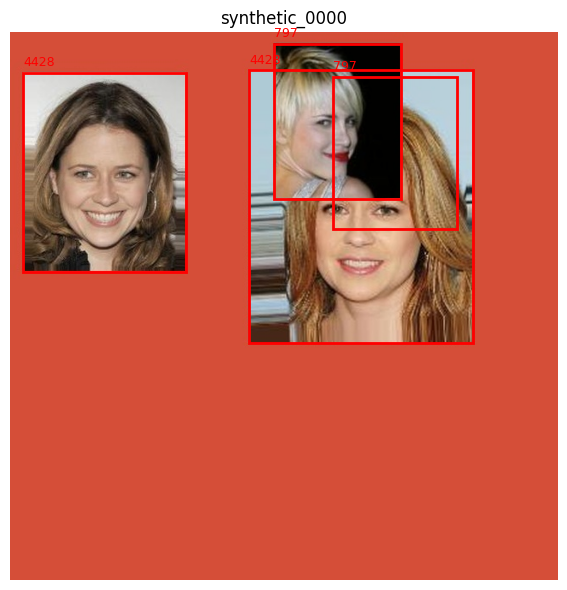

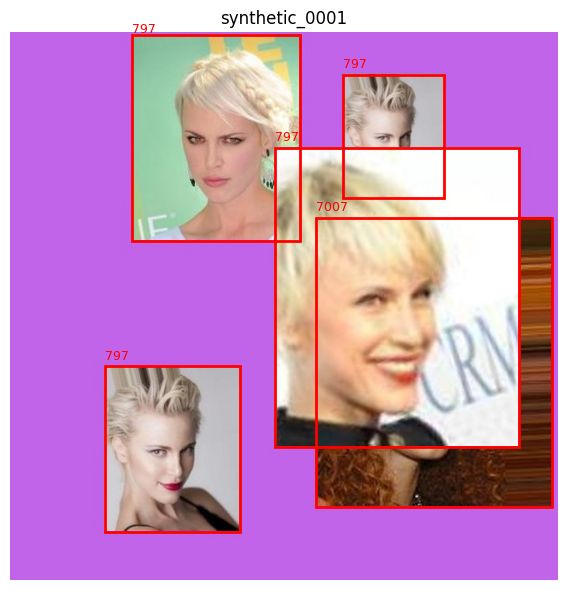

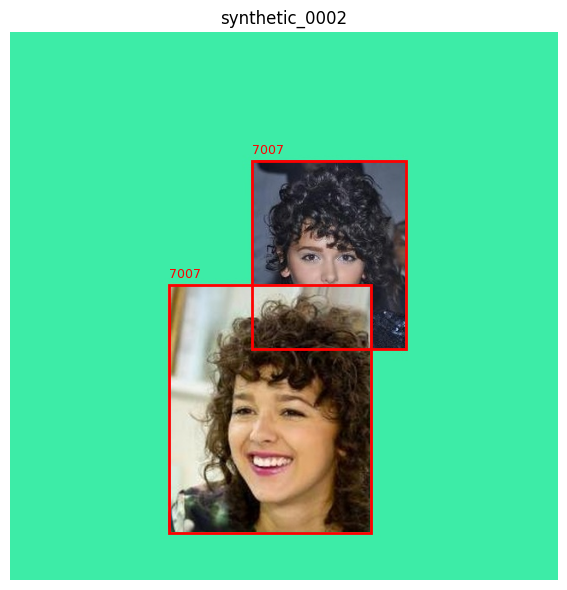

In [8]:
def plot_sample(img_path, label_path, title=""):
    img = Image.open(img_path)
    w, h = img.size
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    
    with open(label_path) as f:
        for line in f.read().strip().splitlines():
            parts = line.split()
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(0, y1-8), CLASS_NAMES[cls], color='red', fontsize=9)
    
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Show 3 random samples
train_imgs = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'images', 'train', '*.jpg')))[:3]
for img_path in train_imgs:
    name = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(OUTPUT_DIR, 'labels', 'train', f'{name}.txt')
    plot_sample(img_path, lbl_path, title=name)

## Summary

| Metric | Value |
|--------|-------|
| Total synthetic images | 200 |
| Faces per image | 2–5 |
| Image size | 640×640 |
| Train / Val / Test | 70% / 15% / 15% |
| Identities | 5 |
| YOLO data.yaml | `data/synthetic_multi_face/data.yaml` |

**Next step:** open `Milestone3_YOLO_FineTune.ipynb` to fine-tune YOLOv8 on this dataset.